In [14]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Display configurations for exhaustive EDA
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', None)

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("Environment setup complete.")

Environment setup complete.


In [15]:
from pathlib import Path
import matplotlib.pyplot as plt

# Define the path to the figures directory (moving up from notebooks/)
FIGURES_DIR = Path('../reports/figures')

# Create the directory if it doesn't exist just in case
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show_plot(filename: str):
    """
    Saves the current matplotlib figure to reports/figures/ and then displays it.
    """
    # Create the full path
    filepath = FIGURES_DIR / filename

    # Save the figure. bbox_inches='tight' prevents axis labels from getting cut off.
    plt.savefig(filepath, bbox_inches='tight', dpi=300)
    print(f"Saved figure to: {filepath.resolve()}")

    # Display the plot in the notebook
    plt.show()

In [16]:
from pathlib import Path
import re
import pandas as pd

def fix_out_of_bounds_dates(df, date_columns):
    """
    Replaces the year in out-of-bounds dates (like 1067) with 2023.
    This allows standard pandas datetime operations for cohort/time analysis.
    """
    for col in date_columns:
        if col in df.columns:
            # Replace the first 4 digits (the year) with 2023
            df[col] = df[col].astype(str).apply(
                lambda x: re.sub(r'^\d{4}', '2023', x) if pd.notnull(x) else x
            )
            # Convert to proper datetime
            df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)
    return df

def load_and_clean_data(base_path: Path, split_name: str):
    # .resolve() prints the absolute path so you can verify it's looking in the right place
    print(f"--- Loading and Cleaning '{split_name}' split from {base_path.resolve()} ---")
    data_dict = {}

    files = {
        'users': f'{split_name}_users.csv',
        'generations': f'{split_name}_users_generations.csv',
        'properties': f'{split_name}_users_properties.csv',
        'purchases': f'{split_name}_users_purchases.csv',
        'quizzes': f'{split_name}_users_quizzes.csv',
        'transactions': f'{split_name}_users_transaction_attempts.csv'
    }

    # Define known date columns across the dataset
    date_cols = ['created_at', 'completed_at', 'failed_at',
                 'subscription_start_date', 'purchase_time', 'transaction_time']

    for key, filename in files.items():
        # Pathlib uses the forward slash operator to join paths cleanly
        filepath = base_path / filename

        # Check if file exists using pathlib
        if filepath.exists():
            df = pd.read_csv(filepath)
            if 'Unnamed: 0' in df.columns:
                df = df.drop(columns=['Unnamed: 0'])

            # Apply date fixing
            df = fix_out_of_bounds_dates(df, date_cols)

            data_dict[key] = df
            print(f"[SUCCESS] {filename} loaded. Shape: {df.shape}")
        else:
            print(f"[SKIPPED] {filename} not found (Workaround applied).")
            data_dict[key] = None

    return data_dict

# ---------------------------------------------------------
# PATH SETUP
# ---------------------------------------------------------
# Since the notebook is in 'notebooks/01_eda.ipynb',
# '..' moves up to the 'hack_higgsfield' root directory.
DATA_DIR = Path('../data/raw')

test_dir = DATA_DIR / 'test'
train_dir = DATA_DIR / 'train'

# Load the data
test_data = load_and_clean_data(test_dir, 'test')
print("\n")
train_data = load_and_clean_data(train_dir, 'train')

--- Loading and Cleaning 'test' split from /Users/ablajabdimalinov/Documents/repos/hack_higgsfield/data/raw/test ---
[SUCCESS] test_users.csv loaded. Shape: (7000, 1)
[SUCCESS] test_users_generations.csv loaded. Shape: (1078213, 11)
[SUCCESS] test_users_properties.csv loaded. Shape: (7000, 4)
[SUCCESS] test_users_purchases.csv loaded. Shape: (8825, 5)
[SUCCESS] test_users_quizzes.csv loaded. Shape: (7000, 9)
[SUCCESS] test_users_transaction_attempts.csv loaded. Shape: (11822, 20)


--- Loading and Cleaning 'train' split from /Users/ablajabdimalinov/Documents/repos/hack_higgsfield/data/raw/train ---
[SUCCESS] train_users.csv loaded. Shape: (90000, 2)
[SUCCESS] train_users_generations.csv loaded. Shape: (28474033, 11)
[SUCCESS] train_users_properties.csv loaded. Shape: (90000, 4)
[SUCCESS] train_users_purchases.csv loaded. Shape: (96424, 5)
[SUCCESS] train_users_quizzes.csv loaded. Shape: (90004, 9)
[SUCCESS] train_users_transaction_attempts.csv loaded. Shape: (178089, 20)


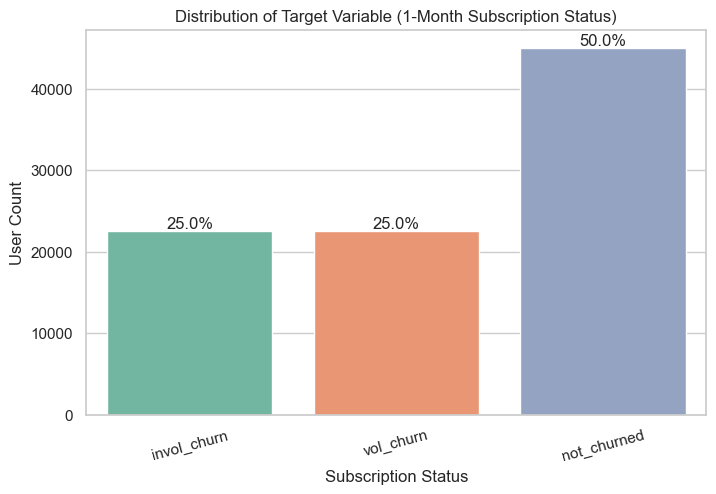

In [17]:
train_users = train_data.get('users')

if train_users is not None and len(train_users.columns) > 1:
    # Assuming the target column is the second column, or named something like 'status' or 'target'
    target_col = train_users.columns[1]

    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=train_users, x=target_col, palette='Set2')
    plt.title('Distribution of Target Variable (1-Month Subscription Status)')
    plt.xlabel('Subscription Status')
    plt.ylabel('User Count')
    plt.xticks(rotation=15)

    # Add percentage labels
    total = len(train_users)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')
    plt.show()
else:
    print("Could not find target variable in train_users. Check column names.")

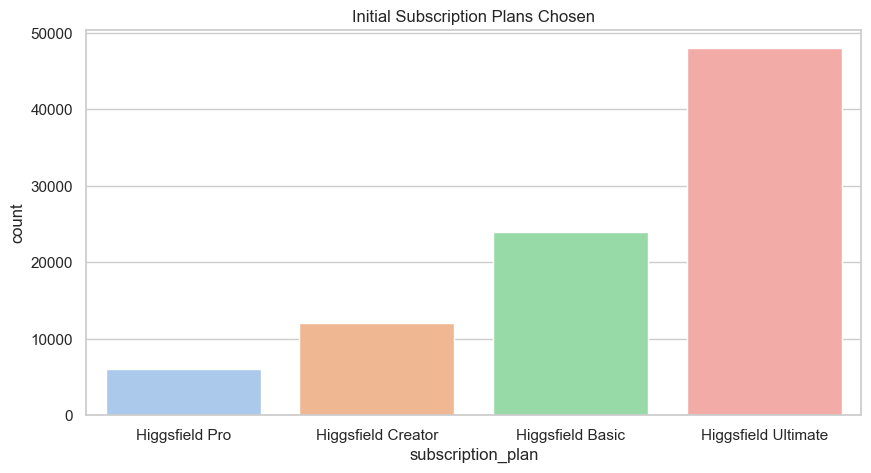

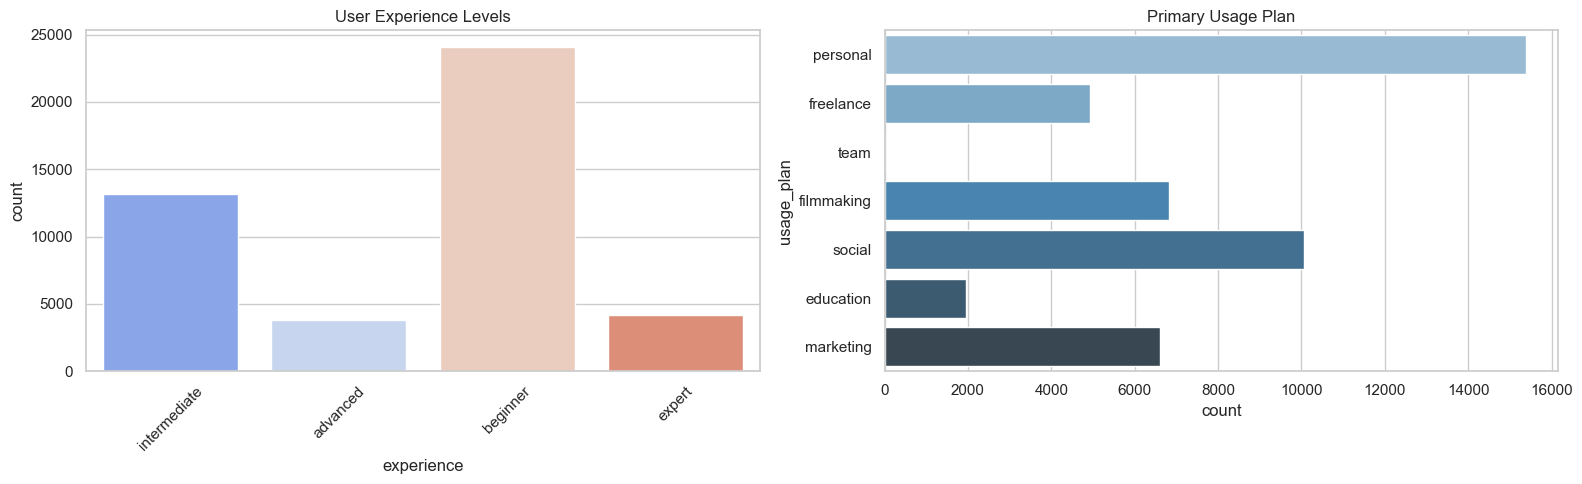

In [18]:
train_props = train_data.get('properties')
train_quizzes = train_data.get('quizzes')

if train_props is not None:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=train_props, x='subscription_plan', palette='pastel')
    plt.title('Initial Subscription Plans Chosen')
    plt.show()

if train_quizzes is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Experience Level
    sns.countplot(data=train_quizzes, x='experience', palette='coolwarm', ax=axes[0])
    axes[0].set_title('User Experience Levels')
    axes[0].tick_params(axis='x', rotation=45)

    # Intended Usage
    sns.countplot(data=train_quizzes, y='usage_plan', palette='Blues_d', ax=axes[1])
    axes[1].set_title('Primary Usage Plan')

    plt.tight_layout()
    plt.show()

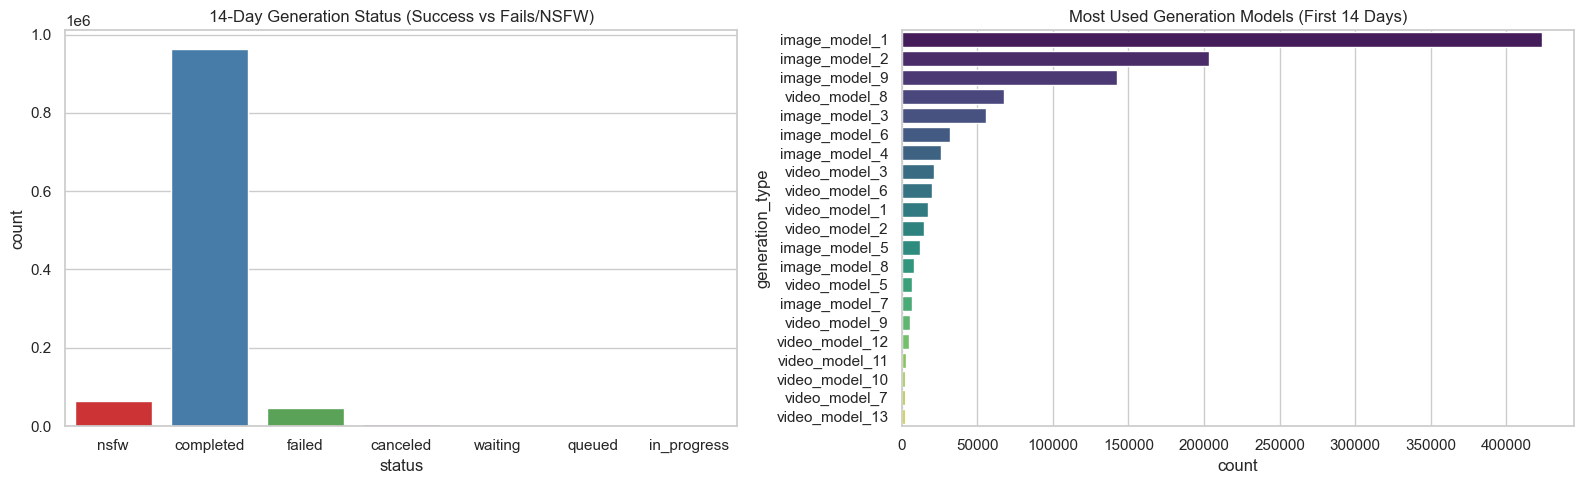

Average processing time (seconds) per model:


generation_type
image_model_7      38.941432
image_model_9      55.495031
video_model_6      58.251112
video_model_13     80.682904
image_model_6      87.728037
video_model_7      91.350782
video_model_1     107.168303
image_model_1     118.651707
image_model_2     119.157297
image_model_8     126.074288
image_model_3     132.376907
video_model_10    141.728387
video_model_9     149.189609
video_model_2     151.268386
video_model_5     159.377447
video_model_11    191.149053
image_model_4     211.246428
image_model_5     230.226924
video_model_12    335.839898
video_model_8     346.824080
video_model_3     570.088154
Name: processing_time_sec, dtype: float64

In [19]:
# Using Test data here since Train generations might be missing based on your previous note
df_gen = test_data.get('generations')

if df_gen is not None:
    # Calculate generation processing time
    df_gen['processing_time_sec'] = (df_gen['completed_at'] - df_gen['created_at']).dt.total_seconds()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Generation Status Distribution
    sns.countplot(data=df_gen, x='status', palette='Set1', ax=axes[0])
    axes[0].set_title('14-Day Generation Status (Success vs Fails/NSFW)')

    # Generation Types (Models) used
    sns.countplot(data=df_gen, y='generation_type', palette='viridis',
                  order=df_gen['generation_type'].value_counts().index, ax=axes[1])
    axes[1].set_title('Most Used Generation Models (First 14 Days)')

    plt.tight_layout()
    plt.show()

    # Aggregated User Behaviors
    print("Average processing time (seconds) per model:")
    display(df_gen.groupby('generation_type')['processing_time_sec'].mean().dropna().sort_values())

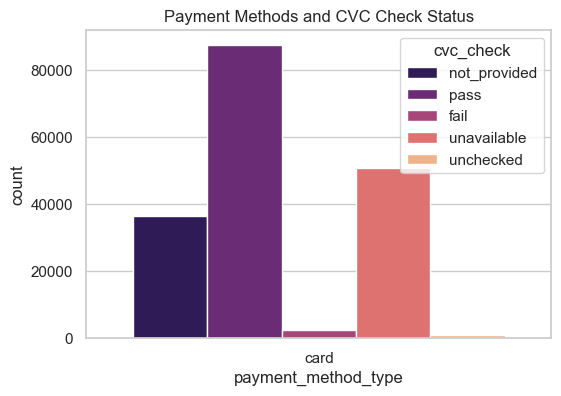

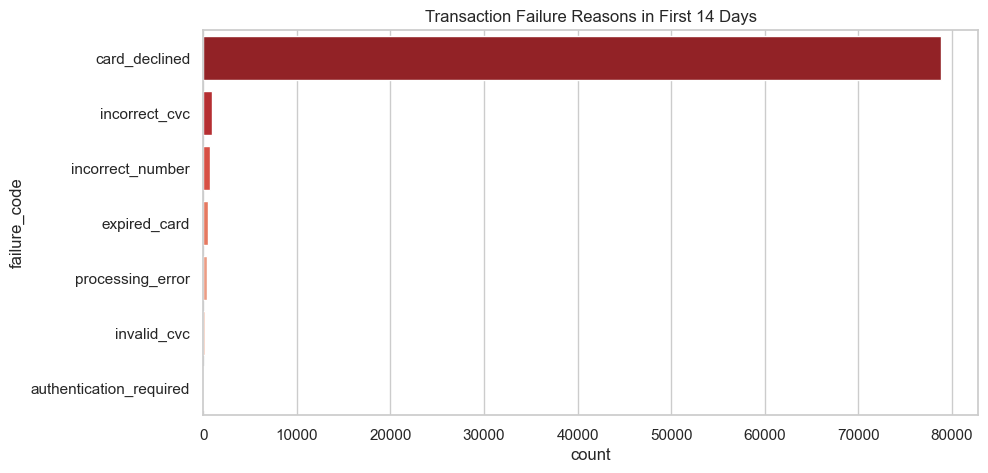

3D Secure Authentication Breakdown:


is_3d_secure_authenticated
False    93.288187
True      6.711813
Name: proportion, dtype: float64

In [20]:
df_tx = train_data.get('transactions')

if df_tx is not None:
    # 1. Overall Transaction Success Rate
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_tx, x='payment_method_type', hue='cvc_check', palette='magma')
    plt.title('Payment Methods and CVC Check Status')
    plt.show()

    # 2. Most common failure reasons (Critical for "Insufficient Funds" churn)
    failed_tx = df_tx[df_tx['failure_code'].notnull()]
    if not failed_tx.empty:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=failed_tx, y='failure_code', palette='Reds_r',
                      order=failed_tx['failure_code'].value_counts().index)
        plt.title('Transaction Failure Reasons in First 14 Days')
        plt.show()

    # 3. 3D Secure Authentication Impact
    if 'is_3d_secure_authenticated' in df_tx.columns:
        print("3D Secure Authentication Breakdown:")
        display(df_tx['is_3d_secure_authenticated'].value_counts(normalize=True) * 100)

In [21]:
# 1. Start with the target table
train_users = train_data.get('users')
train_props = train_data.get('properties')
train_quizzes = train_data.get('quizzes')
df_tx = train_data.get('transactions')
df_purchases = train_data.get('purchases')

if train_users is not None:
    df_features = train_users.copy()

    # 2. Add Properties
    if train_props is not None:
        df_features = df_features.merge(train_props[['user_id', 'subscription_plan', 'country_code']],
                                        on='user_id', how='left')

    # 3. Add Quizzes (Flattened)
    if train_quizzes is not None:
        df_features = df_features.merge(train_quizzes[['user_id', 'experience', 'team_size']],
                                        on='user_id', how='left')

    # 4. Aggregate Transaction Data
    if df_tx is not None and df_purchases is not None:
        # Create a bridge to map transaction_id to user_id
        tx_user_mapping = df_purchases[['transaction_id', 'user_id']].drop_duplicates()

        # Merge the user_id into the transaction attempts table
        df_tx_mapped = df_tx.merge(tx_user_mapping, on='transaction_id', how='inner')

        # Now we can safely group by user_id
        tx_agg = df_tx_mapped.groupby('user_id').agg(
            total_attempts=('transaction_id', 'count'),
            total_failed=('failure_code', lambda x: x.notnull().sum()),
            amount_attempted=('amount_in_usd', 'sum')
        ).reset_index()

        # Calculate failure rate securely (preventing division by zero)
        tx_agg['failure_rate'] = tx_agg['total_failed'] / tx_agg['total_attempts'].replace(0, 1)

        # Merge back to the main feature matrix
        df_features = df_features.merge(tx_agg, on='user_id', how='left')

        # Fill NaNs for users with 0 transactions mapped
        cols_to_fill = ['total_attempts', 'total_failed', 'amount_attempted', 'failure_rate']
        df_features[cols_to_fill] = df_features[cols_to_fill].fillna(0)

    display(HTML("<h3>Aggregated Feature Matrix Preview</h3>"))
    display(df_features.head())

KeyError: 'user_id'

In [10]:
import io
from pathlib import Path

# Define output path
REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
report_path = REPORTS_DIR / 'llm_eda_summary.md'

def generate_llm_report(data_dict, split_name, file_handle):
    file_handle.write(f"# EDA Summary for '{split_name.upper()}' Split\n\n")

    for name, df in data_dict.items():
        file_handle.write(f"## Table: {name.capitalize()}\n\n")

        if df is None:
            file_handle.write("*Dataset missing or skipped.*\n\n")
            continue

        # 1. Shape
        file_handle.write(f"**Shape:** {df.shape[0]} rows, {df.shape[1]} columns\n\n")

        # 2. Missing Values
        missing = df.isnull().sum()
        missing = missing[missing > 0]
        if not missing.empty:
            file_handle.write("### Missing Values\n")
            file_handle.write(pd.DataFrame({'Missing Count': missing}).to_markdown())
            file_handle.write("\n\n")
        else:
            file_handle.write("*No missing values.*\n\n")

        # 3. Descriptive Statistics
        file_handle.write("### Numerical & Categorical Summary\n")
        # Use describe(include='all') and convert to markdown
        file_handle.write(df.describe(include='all').fillna('').to_markdown())
        file_handle.write("\n\n")

        # 4. Top Categorical Distributions
        file_handle.write("### Top Value Distributions (Categorical)\n")
        for col in df.columns:
            # Skip high cardinality ID columns for the text report
            if df[col].nunique() > 50 and 'id' in col.lower():
                continue

            # Grab top 10 most frequent values for context
            val_counts = df[col].value_counts(dropna=False).head(10).reset_index()
            val_counts.columns = [col, 'Count']

            file_handle.write(f"**{col}**\n")
            file_handle.write(val_counts.to_markdown(index=False))
            file_handle.write("\n\n")

    file_handle.write("---\n\n")

# Generate the file
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("# Higgsfield Hackathon Data - Automated EDA Report\n\n")
    generate_llm_report(train_data, 'train', f)
    generate_llm_report(test_data, 'test', f)

print(f"LLM-ready EDA report successfully saved to: {report_path.resolve()}")

LLM-ready EDA report successfully saved to: /Users/ablajabdimalinov/Documents/repos/hack_higgsfield/reports/llm_eda_summary.md
